In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/home/littlejheff/predictops-pipeline/data/raw/ai4i2020.csv')
df.head(20)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(10000, 14)
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [3]:
print(df["Machine failure"].value_counts())
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


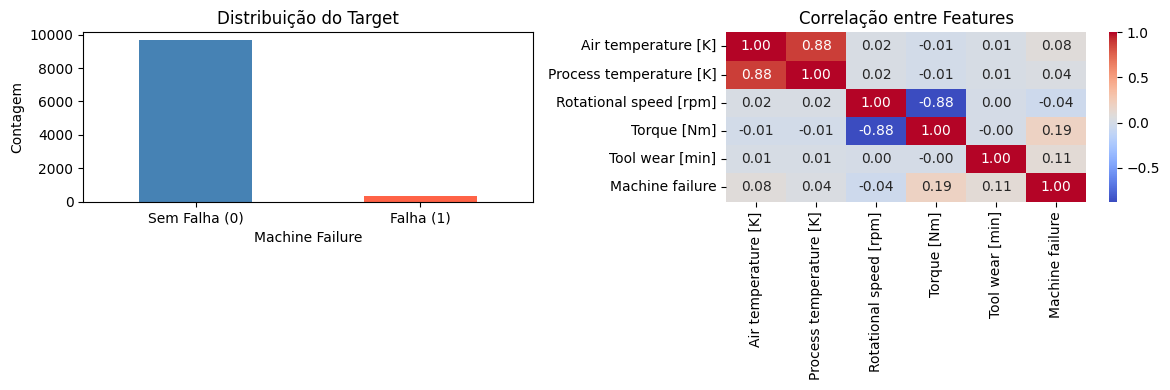

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição do target
df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Distribuição do Target')
axes[0].set_xlabel('Machine Failure')
axes[0].set_ylabel('Contagem')
axes[0].set_xticklabels(['Sem Falha (0)', 'Falha (1)'], rotation=0)

# Correlação entre features numéricas
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 
                'Tool wear [min]', 'Machine failure']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlação entre Features')

plt.tight_layout()
plt.show()

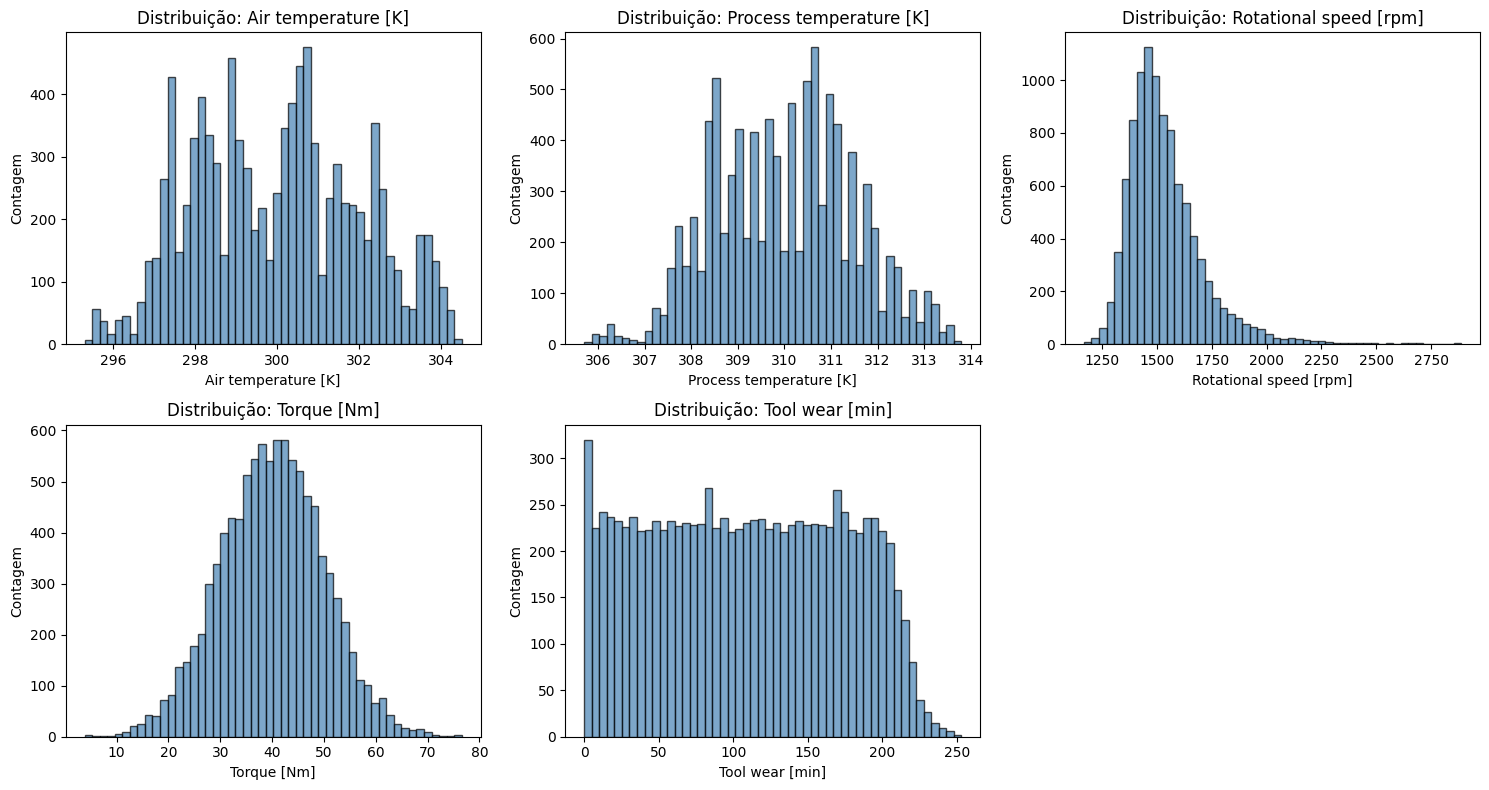

In [6]:
features = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuição: {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Contagem')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

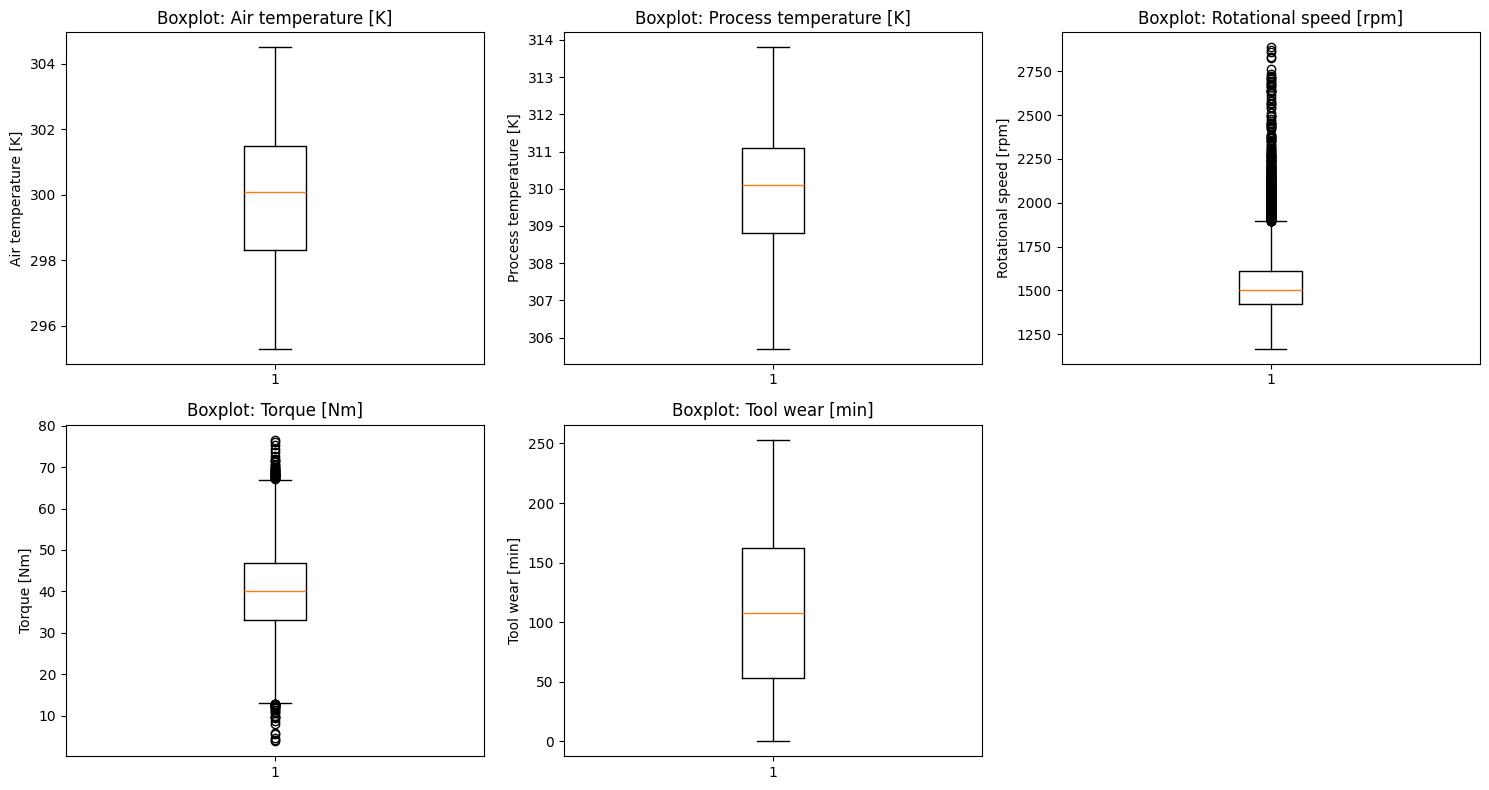

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(df[feature], vert=True)
    axes[i].set_title(f'Boxplot: {feature}')
    axes[i].set_ylabel(feature)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

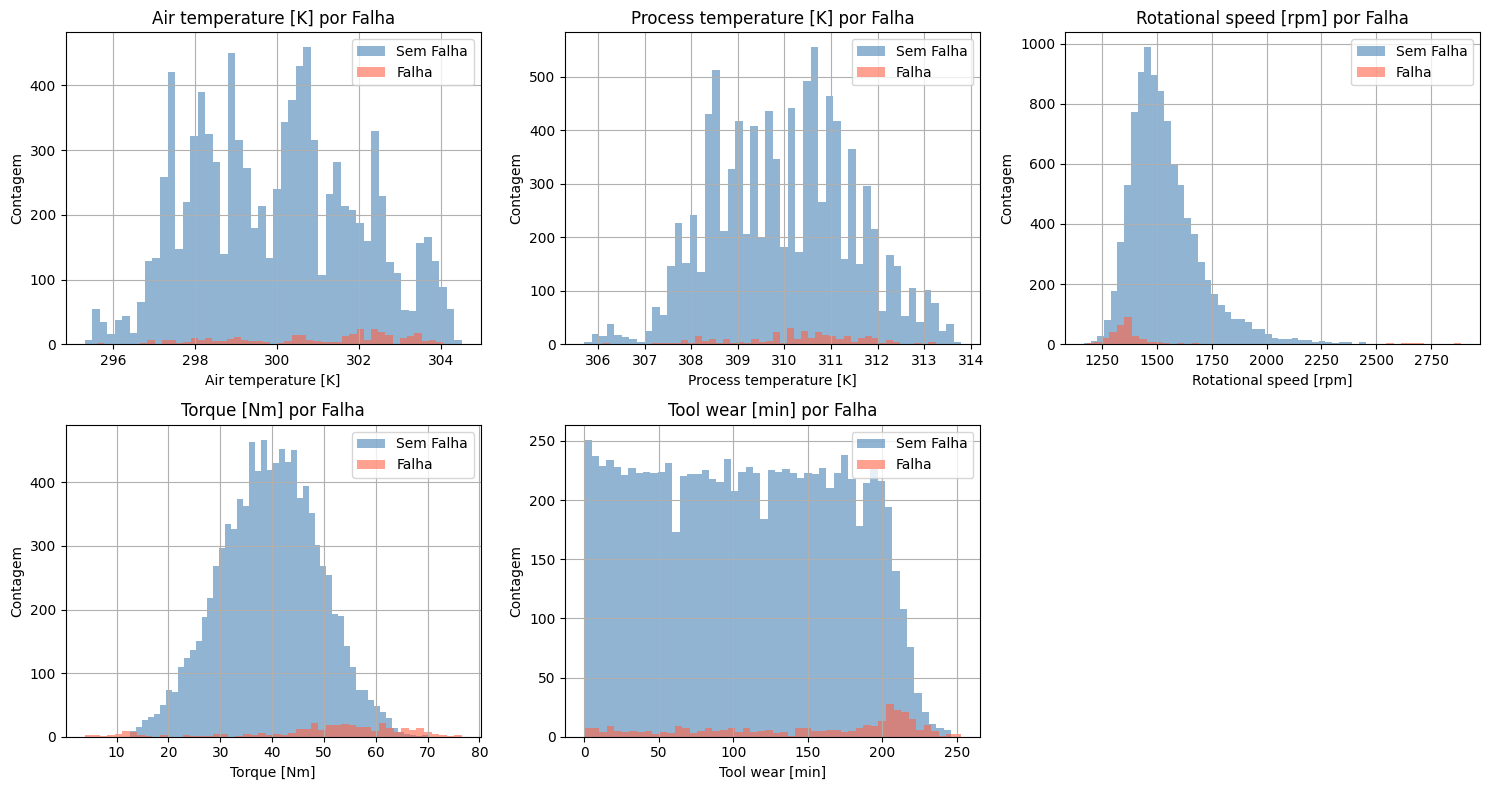

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    df[df['Machine failure'] == 0][feature].hist(
        bins=50, ax=axes[i], alpha=0.6, color='steelblue', label='Sem Falha'
    )
    df[df['Machine failure'] == 1][feature].hist(
        bins=50, ax=axes[i], alpha=0.6, color='tomato', label='Falha'
    )
    axes[i].set_title(f'{feature} por Falha')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Contagem')
    axes[i].legend()

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
import sys
sys.path.append('..')

from src.preprocess import preprocess_pipeline

X_train, X_test, y_train, y_test, scaler = preprocess_pipeline('../data/raw/ai4i2020.csv')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nProporção de falhas no treino: {y_train.mean():.4f}")
print(f"Proporção de falhas no teste: {y_test.mean():.4f}")

X_train shape: (8000, 9)
X_test shape: (2000, 9)
y_train shape: (8000,)
y_test shape: (2000,)

Proporção de falhas no treino: 0.0339
Proporção de falhas no teste: 0.0340


In [10]:
import sys
sys.path.append('..')

from src.preprocess import preprocess_pipeline
import pandas as pd

X_train, X_test, y_train, y_test, scaler = preprocess_pipeline('../data/raw/ai4i2020.csv')

print(f"X_train shape: {X_train.shape}")
print(f"Features totais: {X_train.shape[1]}")

X_train shape: (8000, 9)
Features totais: 9


In [11]:
df_test = pd.read_csv('../data/raw/ai4i2020.csv')
df_test = df_test.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
df_test = df_test.copy()
df_test['temp_diff'] = df_test['Process temperature [K]'] - df_test['Air temperature [K]']
df_test['power'] = df_test['Rotational speed [rpm]'] * df_test['Torque [Nm]']
df_test['tool_wear_torque'] = df_test['Tool wear [min]'] * df_test['Torque [Nm]']

print(df_test[['temp_diff', 'power', 'tool_wear_torque', 'Machine failure']].describe())

          temp_diff         power  tool_wear_torque  Machine failure
count  10000.000000  10000.000000      10000.000000     10000.000000
mean      10.000630  59967.147040       4314.664550         0.033900
std        1.001094  10193.093881       2826.567692         0.180981
min        7.600000  10966.800000          0.000000         0.000000
25%        9.300000  53105.400000       1963.650000         0.000000
50%        9.800000  59883.900000       4012.950000         0.000000
75%       11.000000  66873.750000       6279.000000         0.000000
max       12.100000  99980.400000      16497.000000         1.000000


In [13]:
df_test.head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_diff,power,tool_wear_torque
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,360.0
5,M,298.1,308.6,1425,41.9,11,0,10.5,59707.5,460.9
6,L,298.1,308.6,1558,42.4,14,0,10.5,66059.2,593.6
7,L,298.1,308.6,1527,40.2,16,0,10.5,61385.4,643.2
8,M,298.3,308.7,1667,28.6,18,0,10.4,47676.2,514.8
9,M,298.5,309.0,1741,28.0,21,0,10.5,48748.0,588.0
